# Weekly category planner — walkthrough

Four categories, weekly data ending Sunday, 11 candidate drivers.
This notebook runs the whole pipeline in the order the tool does it:

1. the data
2. **feature selection, separately for every category**
3. **hyperparameter validation, separately for every category**
4. train/test split, then refit on the full history
5. driver impact — which levers matter here, and in which direction
6. forecast the selected drivers, then the two-year baseline
7. a scenario from an edited driver file
8. decomposition

The one architectural rule: **there is no pooled model**. Four categories, four
completely independent models. No shared coefficients, no category fixed effects,
no borrowed hyperparameters. Where you see the categories disagree below — on
which drivers matter, on how much seasonality to fit, on how long media carries
over — that disagreement is the reason.

The panel is synthetic, which means the true elasticities are known and every
estimate below can be checked rather than admired.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import wk_config as cfg, wk_data, wk_features as feat
import wk_model as mdl, wk_selection as sel, wk_scenario as scen

plt.rcParams.update({
    "figure.figsize": (12, 3.6), "axes.grid": True, "grid.color": cfg.GRIDLINE,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": cfg.INK_SECONDARY,
    "text.color": cfg.INK_PRIMARY, "xtick.color": cfg.INK_MUTED,
    "ytick.color": cfg.INK_MUTED, "font.size": 10, "figure.dpi": 110,
})
pd.set_option("display.width", 200)

panel = pd.read_csv(cfg.PANEL_CSV, parse_dates=["date"])
t0 = pd.Timestamp(cfg.HISTORY_START)
print(f"{len(panel)} rows | {panel['date'].nunique()} weeks | "
      f"{panel['date'].min().date()} -> {panel['date'].max().date()}")
print("Every date is a Sunday:", set(panel['date'].dt.day_name()))
panel.head()

964 rows | 241 weeks | 2022-01-02 -> 2026-08-09
Every date is a Sunday: {'Sunday'}


,date,category,volume,avg_price,competitor_price,promo_depth,promo_share,feature_display,distribution_acv,tv_grps,digital_spend,avg_temp_c,cpi_food,consumer_confidence
0,2022-01-02,Baby Formula,514956.0,27.375777,25.859245,9.142307,11.794427,7.884883,61.621116,160.486112,97.815394,4.503747,100.241304,93.867892
1,2022-01-09,Baby Formula,516819.0,26.777150,26.209876,6.494555,10.897387,5.275245,61.204145,125.607564,158.691555,4.688961,100.413844,93.329409
2,2022-01-16,Baby Formula,389027.0,26.780654,26.991080,8.559843,14.988283,5.191469,59.718411,0.000000,95.174225,4.091193,100.686569,93.994003
3,2022-01-23,Baby Formula,397825.0,26.245947,25.458592,9.835754,15.795598,9.063909,61.614537,0.000000,105.576185,3.908166,100.969926,94.439860
4,2022-01-30,Baby Formula,350386.0,27.391034,26.913799,7.645557,9.461811,2.562340,61.819143,0.000000,103.047307,4.192287,101.189728,94.612270


## 1. The data

Four categories that behave nothing like each other. Ice cream triples between
winter and summer; laundry detergent is flat all year. That difference is not a
nuisance to be absorbed by a fixed effect — it is the reason each category needs
its own model.

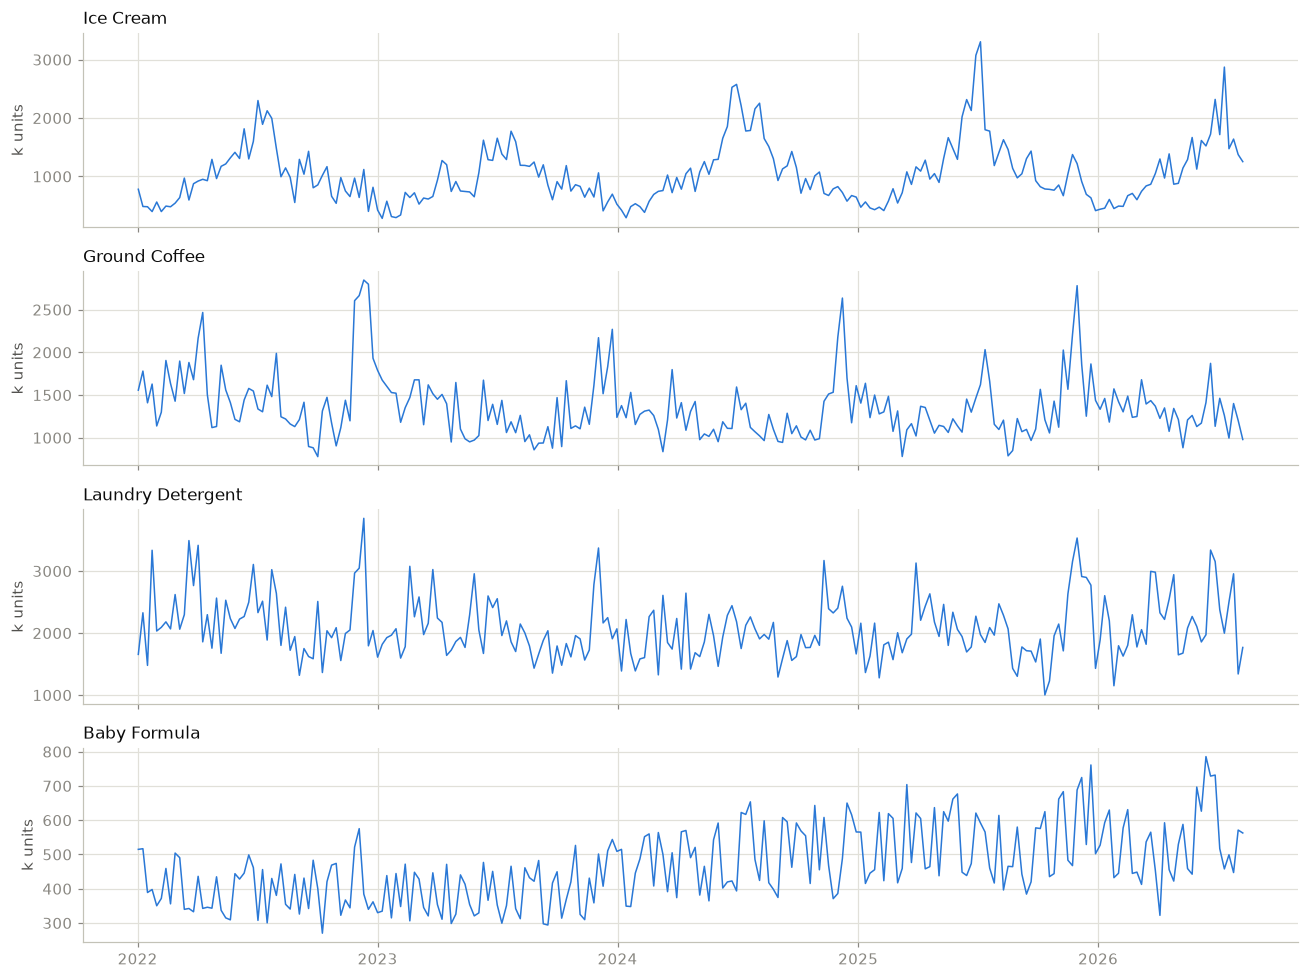

Summer / winter volume ratio:
category
Baby Formula         0.99
Ground Coffee        0.80
Ice Cream            2.97
Laundry Detergent    1.02


In [2]:
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
for ax, cat in zip(axes, cfg.CATEGORIES):
    s = panel[panel.category == cat]
    ax.plot(s["date"], s["volume"] / 1e3, color=cfg.SERIES[0], lw=1)
    ax.set_title(cat, loc="left", fontsize=11, color=cfg.INK_PRIMARY)
    ax.set_ylabel("k units")
plt.tight_layout(); plt.show()

summer = panel[panel.date.dt.month.isin([6, 7, 8])].groupby("category")["volume"].mean()
winter = panel[panel.date.dt.month.isin([12, 1, 2])].groupby("category")["volume"].mean()
print("Summer / winter volume ratio:")
print((summer / winter).round(2).to_string())

The candidate drivers. Some genuinely do nothing in some categories — temperature
does not move laundry detergent, and competitor price does not move baby formula,
because parents do not switch formula on a shelf tag. Those true zeros are what
feature selection has to find.

In [3]:
truth = wk_data.true_elasticity_table()
print("True elasticities (0 = this driver genuinely does nothing in this category):")
truth

True elasticities (0 = this driver genuinely does nothing in this category):


,avg_price,competitor_price,promo_depth,promo_share,feature_display,distribution_acv,tv_grps,digital_spend,avg_temp_c,cpi_food,consumer_confidence
Ice Cream,-1.9,0.55,0.45,0.30,0.35,0.9,0.06,0.030,0.55,-0.3,0.35
Ground Coffee,-2.2,0.70,0.55,0.35,0.25,0.8,0.05,0.055,0.00,-0.7,0.30
Laundry Detergent,-1.2,0.45,0.60,0.40,0.30,1.0,0.03,0.020,0.00,-0.5,0.20
Baby Formula,-0.6,0.00,0.20,0.15,0.00,1.1,0.07,0.060,0.00,-0.4,0.45


## 2. Feature selection, per category

Backward elimination scored on **expanding-window cross-validation**: always train
on the past and test on the future, because a forecasting model that gets to see
next winter while predicting last winter is not being tested.

Start with all 11 drivers. Repeatedly ask "what happens to out-of-fold error if I
drop this one?", and drop the cheapest — while it stays cheap.

Two guards stop pure error-chasing from building the wrong tool:

- a driver whose **unconstrained** elasticity contradicts its business prior is
  removed first (if the data says raising price raises volume, this category
  cannot identify price, and the fix is not to constrain the coefficient to zero
  and keep it);
- a **controllable and material** driver is never eliminated. See section 2b.

Selection runs on the **training rows only** — selecting on all 241 weeks and then
reporting accuracy on the last 52 would leak the test set into the feature list.

In [4]:
cat = "Ground Coffee"
df = panel[panel.category == cat].sort_values("date").reset_index(drop=True)
train, test = df[df.date <= df.date.max() - pd.Timedelta(weeks=cfg.TEST_WEEKS)], \
              df[df.date > df.date.max() - pd.Timedelta(weeks=cfg.TEST_WEEKS)]
print(f"{cat}: train {len(train)} weeks, test {len(test)} weeks\n")

result = sel.select_for_category(train, cat, t0)
print(f"\nKept    ({len(result['selected'])}): {', '.join(result['selected'])}")
print(f"Dropped ({len(result['dropped'])}): {', '.join(result['dropped']) or 'none'}")

Ground Coffee: train 189 weeks, test 52 weeks

    [1/4] tuning shape with all 11 drivers ...


          k=3, decay=0.5, alpha=3.0
    [2/4] checking elasticity signs against the business prior ...
          dropped for wrong sign: none
    [3/4] backward elimination on out-of-fold error ...
      drop cpi_food               -> 10 drivers, cv_rmse 0.06255


      drop avg_temp_c             ->  9 drivers, cv_rmse 0.06218
    [4/4] re-tuning shape on the 9 selected drivers ...


          k=3, decay=0.5, alpha=0.5

Kept    (9): avg_price, competitor_price, promo_depth, promo_share, feature_display, distribution_acv, tv_grps, digital_spend, consumer_confidence
Dropped (2): avg_temp_c, cpi_food


In [5]:
print("Backward elimination trace — each row drops the driver that costs least:")
result["elimination_log"]

Backward elimination trace — each row drops the driver that costs least:


,step,removed,n_drivers,cv_rmse,alpha
0,0,NaN,11,0.063498,3.0
1,1,cpi_food,10,0.062546,1.0
2,2,avg_temp_c,9,0.062185,0.5


### 2b. Why forecast error alone builds the wrong tool

The first version of this experiment selected purely on cross-validated error, and
it dropped `avg_price` from Laundry Detergent while keeping `competitor_price`.

That is not a bug in the search. Our price and the competitor's price move together
— both track food CPI, both respond to the same promo calendar — so out-of-fold
error genuinely cannot separate them. Swapping one for the other costs nothing you
can measure with RMSE.

As a *forecast*, fine. As a *planning tool*, useless: it deletes the one number the
category team actually sets and replaces it with a number they can only watch.

So a driver marked `controllable` in the config is protected from elimination when
its estimated impact clears `MATERIALITY_PCT`. The threshold is what keeps this
from becoming blanket protection — a controllable driver the model finds genuinely
inert is still dropped, which is exactly what happens to feature+display in baby
formula, whose true elasticity is zero.

In [6]:
# Same category, same data, with lever protection turned off.
import copy
saved = cfg.MATERIALITY_PCT
cfg.MATERIALITY_PCT = 1e9  # nothing is protected

shape, _ = mdl.choose_config(
    panel[panel.category == "Laundry Detergent"].pipe(
        lambda d: d[d.date <= d.date.max() - pd.Timedelta(weeks=cfg.TEST_WEEKS)]),
    list(cfg.DRIVER_NAMES), t0)
ld_train = panel[panel.category == "Laundry Detergent"].pipe(
    lambda d: d[d.date <= d.date.max() - pd.Timedelta(weeks=cfg.TEST_WEEKS)])
unprotected, _ = sel.backward_eliminate(
    ld_train, list(cfg.DRIVER_NAMES), shape["fourier_k"], shape["adstock_decay"], t0)

cfg.MATERIALITY_PCT = saved
protected, _ = sel.backward_eliminate(
    ld_train, list(cfg.DRIVER_NAMES), shape["fourier_k"], shape["adstock_decay"], t0)

print("Laundry Detergent, selection WITHOUT lever protection:")
print("  ", ", ".join(unprotected))
print("   avg_price kept?", "avg_price" in unprotected)
print("\nLaundry Detergent, selection WITH lever protection:")
print("  ", ", ".join(protected))
print("   avg_price kept?", "avg_price" in protected)

Laundry Detergent, selection WITHOUT lever protection:
   competitor_price, promo_depth, promo_share, feature_display, distribution_acv, tv_grps, cpi_food
   avg_price kept? False

Laundry Detergent, selection WITH lever protection:
   avg_price, competitor_price, promo_depth, promo_share, feature_display, distribution_acv, tv_grps, cpi_food
   avg_price kept? True


## 3. Hyperparameter validation, per category

Three things are tuned, and all three genuinely differ between categories:

| | what it controls |
|---|---|
| `fourier_k` | how many harmonics the yearly seasonality gets |
| `adstock_decay` | how long media carries over |
| `alpha` | ridge strength on the elasticities |

Every combination is scored on the same expanding-window folds. Ice cream needs a
richer seasonal shape than baby formula; laundry's media carries over for weeks
while baby formula's does not carry at all. One global config would be wrong for
at least three of the four.

In [7]:
print(f"{cat}: top 8 of {len(result['grid'])} configurations")
result["grid"].head(8)

Ground Coffee: top 8 of 112 configurations


,fourier_k,adstock_decay,alpha,cv_rmse
0,3,0.5,0.50,0.062185
1,3,0.5,1.00,0.062239
2,3,0.5,0.10,0.062319
3,3,0.5,0.01,0.062382
4,3,0.5,3.00,0.063369
5,4,0.5,1.00,0.063938
6,4,0.5,0.50,0.064132
7,4,0.5,0.10,0.064617


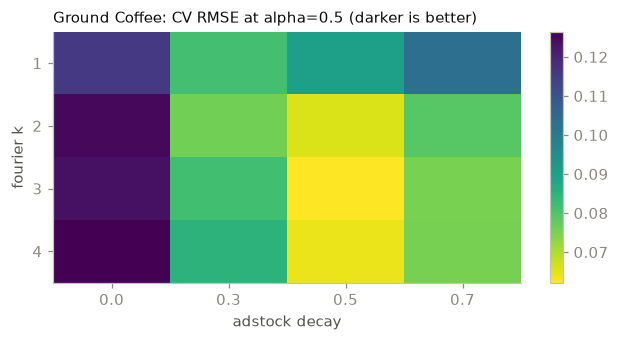

In [8]:
g = result["grid"]
best_alpha = g.iloc[0]["alpha"]
sub = g[g.alpha == best_alpha].pivot(index="fourier_k", columns="adstock_decay",
                                     values="cv_rmse")
fig, ax = plt.subplots(figsize=(6, 3.2))
im = ax.imshow(sub.values, cmap="viridis_r", aspect="auto")
ax.set_xticks(range(len(sub.columns)), sub.columns)
ax.set_yticks(range(len(sub.index)), sub.index)
ax.set_xlabel("adstock decay"); ax.set_ylabel("fourier k")
ax.set_title(f"{cat}: CV RMSE at alpha={best_alpha} (darker is better)",
             loc="left", fontsize=10)
ax.grid(False); plt.colorbar(im); plt.tight_layout(); plt.show()

## 4. Train / test, then refit on everything

The test score comes from a model that saw neither the test weeks nor — crucially
— let them influence which features exist.

The model that actually ships is refitted on the full history with the same
recipe. Holding out the most recent year forever, just to preserve a number
already recorded, would throw away the most relevant data in the panel.

Trained on the first 189 weeks only:
  train: {'n_weeks': 189, 'mape': 3.077, 'wape': 3.122, 'r2_log': 0.976, 'bias_pct': -0.114}
  test : {'n_weeks': 52, 'mape': 7.018, 'wape': 7.211, 'r2_log': 0.849, 'bias_pct': -6.956}

Refitted on all 241 weeks -- this is the model that ships.


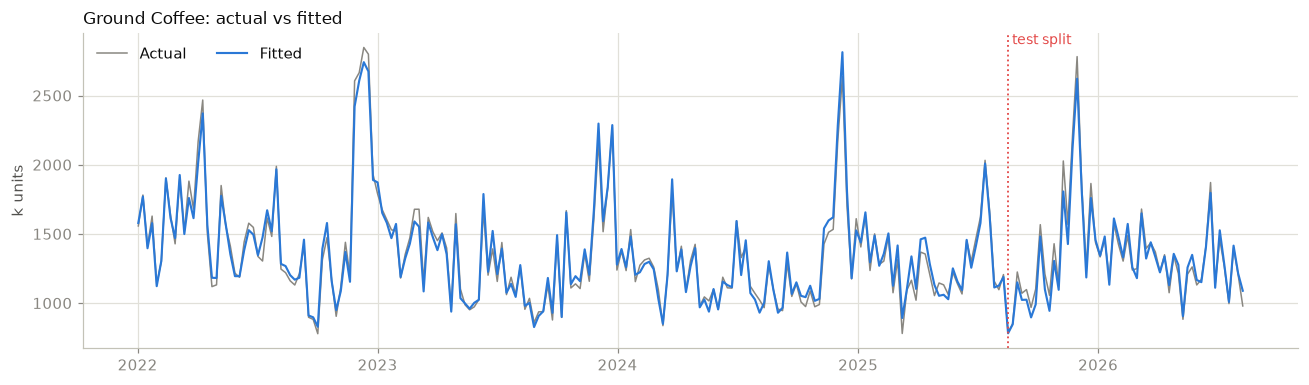

In [9]:
train_model = mdl.fit_category(train, cat, result["selected"], result["config"], t0)
print("Trained on the first", len(train), "weeks only:")
print("  train:", {k: round(v, 3) for k, v in mdl.score(train_model, train).items()})
print("  test :", {k: round(v, 3) for k, v in mdl.score(train_model, test).items()})

final = mdl.fit_category(df, cat, result["selected"], result["config"], t0)
print("\nRefitted on all", len(df), "weeks -- this is the model that ships.")

fig, ax = plt.subplots()
ax.plot(df["date"], df["volume"] / 1e3, color=cfg.INK_MUTED, lw=1, label="Actual")
ax.plot(df["date"], final.predict(df) / 1e3, color=cfg.SERIES[0], lw=1.4, label="Fitted")
ax.axvline(test["date"].min(), color=cfg.NEG, ls=":", lw=1.2)
ax.text(test["date"].min(), ax.get_ylim()[1], " test split", va="top",
        fontsize=9, color=cfg.NEG)
ax.set_ylabel("k units"); ax.legend(frameon=False, ncol=2)
ax.set_title(f"{cat}: actual vs fitted", loc="left", fontsize=11)
plt.tight_layout(); plt.show()

Now every category, end to end. This is exactly what `build.py` does.

In [10]:
models, rows = {}, []
for c in cfg.CATEGORIES:
    d = panel[panel.category == c].sort_values("date").reset_index(drop=True)
    cut = d.date.max() - pd.Timedelta(weeks=cfg.TEST_WEEKS)
    tr, te = d[d.date <= cut], d[d.date > cut]
    r = sel.select_for_category(tr, c, t0, verbose=False)
    tm = mdl.fit_category(tr, c, r["selected"], r["config"], t0)
    fm = mdl.fit_category(d, c, r["selected"], r["config"], t0)
    fm.metrics = {"train": mdl.score(tm, tr), "test": mdl.score(tm, te)}
    fm.selection = r
    models[c] = fm
    rows.append({"category": c, "drivers": len(r["selected"]),
                 **r["config"],
                 "test MAPE %": fm.metrics["test"]["mape"],
                 "test R2 log": fm.metrics["test"]["r2_log"]})
pd.DataFrame(rows).set_index("category").round(3)

,drivers,fourier_k,adstock_decay,alpha,test MAPE %,test R2 log
category,,,,,,
Ice Cream,10,3,0.5,0.01,7.885,0.937
Ground Coffee,9,3,0.5,0.50,7.018,0.849
Laundry Detergent,8,1,0.7,3.00,3.820,0.969
Baby Formula,8,1,0.0,0.01,4.640,0.915


Read the `fourier_k` and `adstock_decay` columns above against the truth in
`wk_config.CATEGORY_SHAPE`. The categories were generated with different seasonal
shapes and different media carryover, and validating each one separately recovers
that. A single shared config could not have.

In [11]:
print("Selected drivers, per category:\n")
for c, m in models.items():
    dropped = [d for d in cfg.DRIVER_NAMES if d not in m.drivers]
    print(f"{c}\n   kept    ({len(m.drivers)}): {', '.join(m.drivers)}")
    print(f"   dropped ({len(dropped)}): {', '.join(dropped) or 'none'}\n")

print("Did selection find the true zeros?")
for c, m in models.items():
    zeros = [d for d in cfg.DRIVER_NAMES if truth.loc[c, d] == 0]
    found = [d for d in zeros if d not in m.drivers]
    kept_real = [d for d in cfg.DRIVER_NAMES if truth.loc[c, d] != 0 and d in m.drivers]
    print(f"  {c:<20} true zeros dropped {len(found)}/{len(zeros)}   "
          f"real drivers kept {len(kept_real)}/{int((truth.loc[c] != 0).sum())}")

Selected drivers, per category:

Ice Cream
   kept    (10): avg_price, competitor_price, promo_depth, promo_share, feature_display, distribution_acv, tv_grps, digital_spend, avg_temp_c, consumer_confidence
   dropped (1): cpi_food

Ground Coffee
   kept    (9): avg_price, competitor_price, promo_depth, promo_share, feature_display, distribution_acv, tv_grps, digital_spend, consumer_confidence
   dropped (2): avg_temp_c, cpi_food

Laundry Detergent
   kept    (8): avg_price, competitor_price, promo_depth, promo_share, feature_display, distribution_acv, tv_grps, cpi_food
   dropped (3): digital_spend, avg_temp_c, consumer_confidence

Baby Formula
   kept    (8): avg_price, promo_depth, promo_share, distribution_acv, tv_grps, digital_spend, avg_temp_c, consumer_confidence
   dropped (3): competitor_price, feature_display, cpi_food

Did selection find the true zeros?
  Ice Cream            true zeros dropped 0/0   real drivers kept 10/11
  Ground Coffee        true zeros dropped 1/1   real

## 5. Driver impact — which levers matter, and which way

Two numbers, and the difference between them matters:

- **elasticity** — % change in volume for a 1% change in the driver.
- **impact** — % change in volume for a *one-standard-deviation* move in the
  driver, using that category's own history.

Elasticity alone overstates a driver that never moves. A −2.2 price elasticity on
a price that varies by 3% is a smaller lever than a +0.06 media elasticity on a
budget that swings by half. Impact is the one to plan against; elasticity is the
one to sanity-check against the truth.

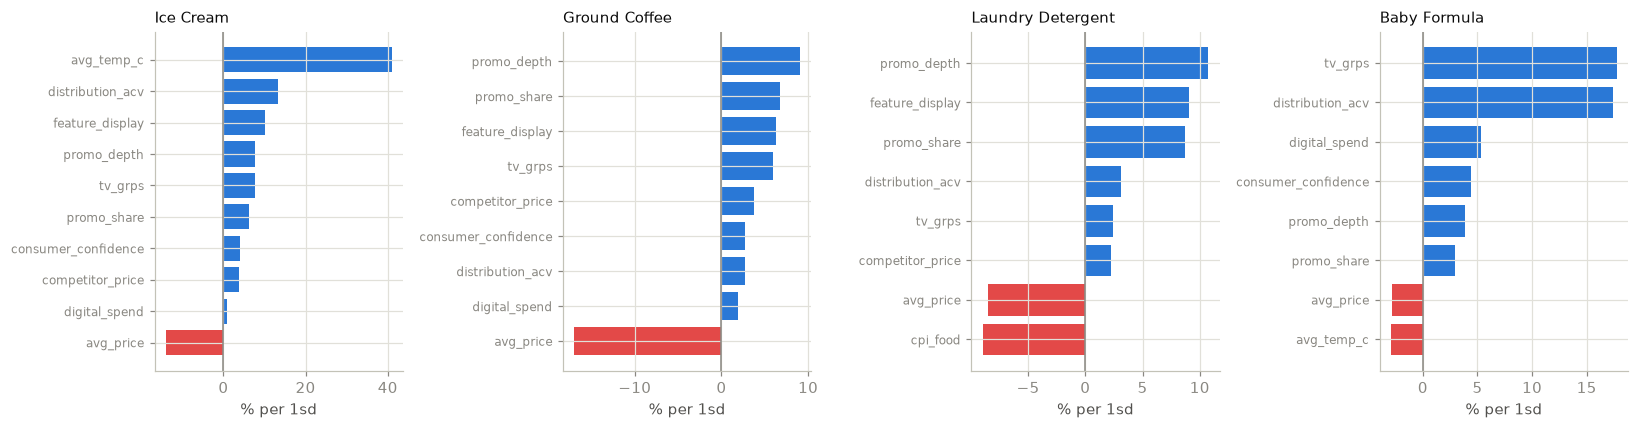

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, (c, m) in zip(axes, models.items()):
    imp = m.impacts().sort_values("impact_pct")
    colors = [cfg.POS if v > 0 else cfg.NEG for v in imp["impact_pct"]]
    ax.barh(range(len(imp)), imp["impact_pct"], color=colors)
    ax.set_yticks(range(len(imp)), imp["driver"], fontsize=8)
    ax.axvline(0, color=cfg.INK_MUTED, lw=1)
    ax.set_title(c, loc="left", fontsize=10)
    ax.set_xlabel("% per 1sd")
plt.tight_layout(); plt.show()

In [13]:
print(f"{cat} -- impact table as the app shows it:")
models[cat].impacts().round(3)

Ground Coffee -- impact table as the app shows it:


,driver,label,group,elasticity,log_sd,impact_pct,direction
0,avg_price,Average price ($/unit),Price,-2.853,0.065,-16.971,decreases volume
1,promo_depth,Promo depth (avg % off),Promotion,0.518,0.167,9.058,increases volume
2,promo_share,Stores on promo (% ACV),Promotion,0.323,0.204,6.805,increases volume
3,feature_display,Feature + display (% ACV),Promotion,0.222,0.274,6.290,increases volume
4,tv_grps,TV GRPs,Media,0.043,1.339,5.916,increases volume
5,competitor_price,Competitor avg price ($/unit),Price,0.551,0.066,3.725,increases volume
6,consumer_confidence,Consumer confidence,External,0.306,0.086,2.678,increases volume
7,distribution_acv,Distribution (% ACV),Distribution,0.359,0.073,2.659,increases volume
8,digital_spend,Digital spend ($k),Media,0.077,0.244,1.902,increases volume


In [14]:
est = pd.DataFrame({c: {d: float(models[c].elasticities.get(d, 0.0))
                        for d in cfg.DRIVER_NAMES} for c in cfg.CATEGORIES}).T
err = (est - truth).abs()
print("Estimated elasticity (dropped drivers show as 0):")
print(est.round(3).to_string())
print("\nMean absolute error vs the truth, per category:")
print(err.mean(axis=1).round(4).to_string())

Estimated elasticity (dropped drivers show as 0):
                   avg_price  competitor_price  promo_depth  promo_share  feature_display  distribution_acv  tv_grps  digital_spend  avg_temp_c  cpi_food  consumer_confidence
Ice Cream             -2.094             0.516        0.423        0.274            0.364             1.443    0.083          0.033       0.540     0.000                0.463
Ground Coffee         -2.853             0.551        0.518        0.323            0.222             0.359    0.043          0.077       0.000     0.000                0.306
Laundry Detergent     -1.161             0.327        0.612        0.373            0.297             0.632    0.024          0.000       0.000    -1.228                0.000
Baby Formula          -0.453             0.000        0.232        0.147            0.000             1.493    0.070          0.060      -0.046     0.000                0.499

Mean absolute error vs the truth, per category:
Ice Cream            0.117

## 6. Forecast the selected drivers, then the baseline

Each `(category, driver)` pair is forecast on its own — the same driver can look
completely different for two categories, and nothing forces them to agree.

Only **selected** drivers are forecast. That is most of the practical payoff of
doing selection first: the forecasting work, and the maintenance of those
forecasts, scales with the drivers you actually use rather than with everything
you happen to collect.

Then the baseline: 104 weeks of volume on those driver paths.

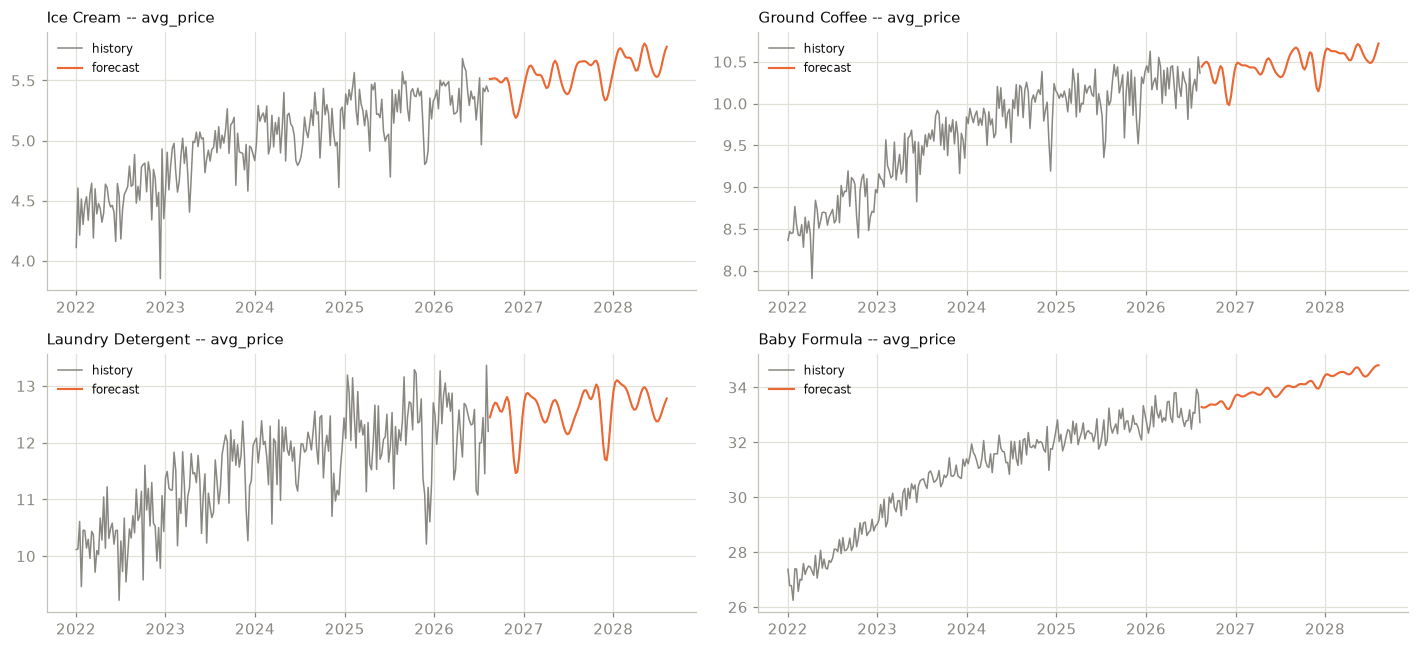

In [15]:
import wk_drivers
driver_fc = pd.read_csv(cfg.DRIVER_FORECAST_CSV, parse_dates=["date"])
models_built = mdl.load()   # the artifacts build.py wrote

fig, axes = plt.subplots(2, 2, figsize=(13, 6))
for ax, c in zip(axes.ravel(), cfg.CATEGORIES):
    h = panel[panel.category == c]
    f = driver_fc[driver_fc.category == c]
    ax.plot(h["date"], h["avg_price"], color=cfg.INK_MUTED, lw=1, label="history")
    ax.plot(f["date"], f["avg_price"], color=cfg.SERIES[1], lw=1.4, label="forecast")
    ax.set_title(f"{c} -- avg_price", loc="left", fontsize=10)
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

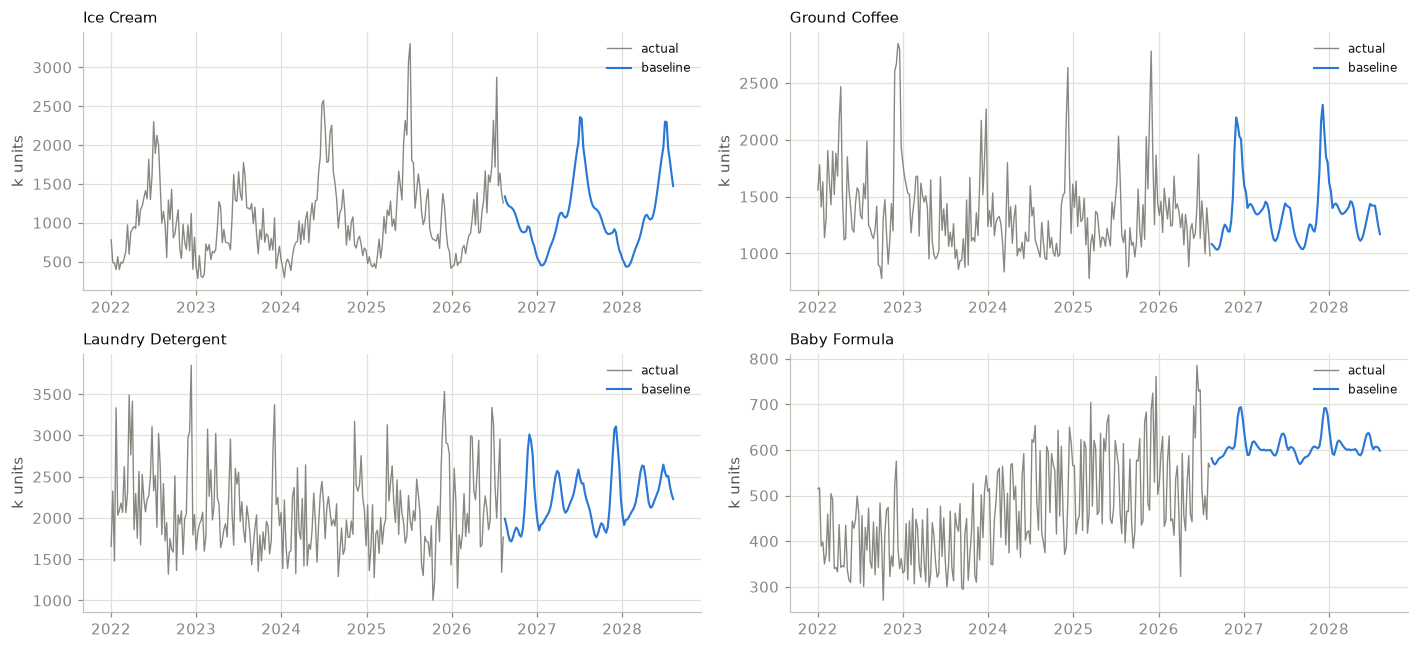

Two-year baseline volume:
category
Baby Formula          63276147.0
Ground Coffee        142682787.0
Ice Cream            113405882.0
Laundry Detergent    231018792.0


In [16]:
base = pd.read_csv(cfg.BASELINE_CSV, parse_dates=["date"])
fig, axes = plt.subplots(2, 2, figsize=(13, 6))
for ax, c in zip(axes.ravel(), cfg.CATEGORIES):
    b = base[base.category == c]
    h, f = b[b.period == "history"], b[b.period == "forecast"]
    ax.plot(h["date"], h["volume_actual"] / 1e3, color=cfg.INK_MUTED, lw=0.9,
            label="actual")
    ax.plot(f["date"], f["volume_baseline"] / 1e3, color=cfg.SERIES[0], lw=1.4,
            label="baseline")
    ax.set_title(c, loc="left", fontsize=10); ax.set_ylabel("k units")
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

print("Two-year baseline volume:")
print(base[base.period == "forecast"].groupby("category")["volume_baseline"]
      .sum().round(0).to_string())

## 7. A scenario

This is the loop the Streamlit app implements:

    download  ->  a CSV of this category's drivers, history and forecast together
    edit      ->  in Excel, by whoever knows the plan
    upload    ->  the edited forecast rows become the scenario

A file rather than sliders, because sliders can only say "everything moves by X%".
A real plan is "price holds until March then rises 4%, and we pull the May display
event forward two weeks" — a column of numbers.

Below, the edit is done in pandas instead of Excel, but it is the identical code
path the upload takes.

In [17]:
cat2 = "Ice Cream"
m2 = models_built[cat2]
edited = base[base.category == cat2].copy()
fut = edited["period"] == "forecast"

# The plan: +4% price from 2027, and a heavier summer media push.
edited.loc[fut & (edited.date.dt.year >= 2027), "avg_price"] *= 1.04
summer = fut & edited.date.dt.month.isin([5, 6, 7])
edited.loc[summer, "tv_grps"] *= 1.5

problems = scen.validate_upload(edited, m2, driver_fc)
print("Validation:", problems or "file is usable")

r = scen.run_scenario(m2, panel, driver_fc, edited)
s = r["summary"]
print(f"\nBaseline  {s['baseline_volume']:>14,.0f}")
print(f"Scenario  {s['scenario_volume']:>14,.0f}")
print(f"Change    {s['delta_volume']:>+14,.0f}   ({s['delta_pct']:+.2f}%)")

Validation: file is usable

Baseline     113,405,882
Scenario     107,413,473
Change        -5,992,410   (-5.28%)


What changed in the plan:


,driver,label,baseline_avg,scenario_avg,pct_change,weeks_changed
0,avg_price,Average price ($/unit),5.56,5.74,3.25,84
1,tv_grps,TV GRPs,52.96,60.50,14.24,26



Where the volume difference comes from:


,driver,label,group,delta_volume,delta_pct
0,avg_price,Average price ($/unit),Price,-7433136.5,-6.6
1,tv_grps,TV GRPs,Media,1440726.9,1.3


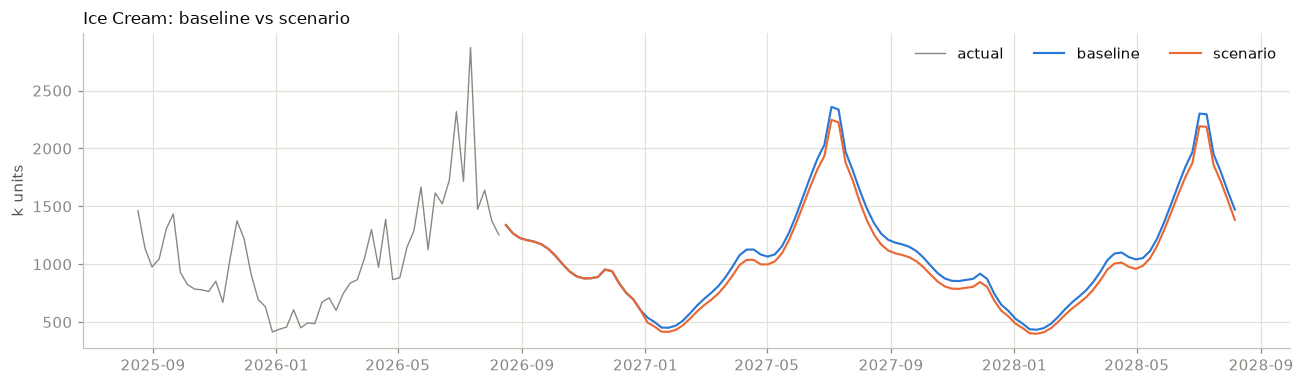

In [18]:
print("What changed in the plan:")
display(r["changes"].round(2))
print("\nWhere the volume difference comes from:")
display(r["waterfall"].round(1))

fig, ax = plt.subplots()
p = r["paths"]
h = panel[panel.category == cat2].tail(52)
ax.plot(h["date"], h["volume"] / 1e3, color=cfg.INK_MUTED, lw=0.9, label="actual")
ax.plot(p["date"], p["baseline"] / 1e3, color=cfg.SERIES[0], lw=1.4, label="baseline")
ax.plot(p["date"], p["scenario"] / 1e3, color=cfg.SERIES[1], lw=1.4, label="scenario")
ax.set_ylabel("k units"); ax.legend(frameon=False, ncol=3)
ax.set_title(f"{cat2}: baseline vs scenario", loc="left", fontsize=11)
plt.tight_layout(); plt.show()

Note the shape of the difference: the media uplift only appears in summer weeks,
and it decays for a few weeks after each burst rather than stopping dead — that is
the validated adstock carrying over. The price effect only starts in 2027. The
model responds to *when* the plan changes, not just to how much.

## 8. Decomposition

The model is additive in logs, so predicted volume splits cleanly into a base plus
each block's deviation from its own historic average. Contributions are converted
back to units multiplicatively, so the parts sum **exactly** to the prediction
rather than approximately.

`base` is volume at this category's average driver levels with trend, seasonality
and holidays at their historic means. Everything else is deviation from that.

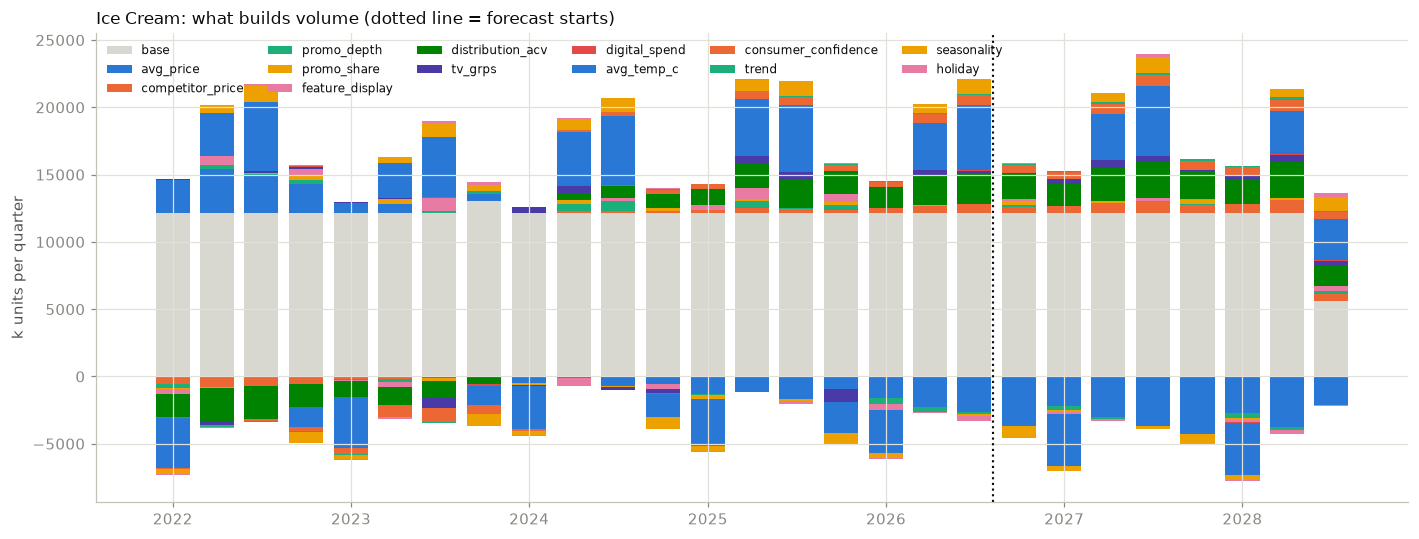

Parts sum to prediction, max relative error: 8.88e-16


In [19]:
dec = scen.decompose_period(models_built[cat2], panel, driver_fc)
dec["quarter"] = pd.PeriodIndex(dec["date"], freq="Q").to_timestamp()
blocks = [c for c in dec.columns
          if c not in ("date", "predicted", "period", "quarter", "base")]
q = dec.groupby("quarter")[["base"] + blocks].sum()

fig, ax = plt.subplots(figsize=(13, 5))
bottom_pos = np.zeros(len(q)); bottom_neg = np.zeros(len(q))
ax.bar(q.index, q["base"] / 1e3, width=70, color="#d9d8d0", label="base")
bottom_pos += q["base"].values / 1e3
for i, b in enumerate(blocks):
    v = q[b].values / 1e3
    pos, neg = np.clip(v, 0, None), np.clip(v, None, 0)
    ax.bar(q.index, pos, width=70, bottom=bottom_pos,
           color=cfg.SERIES[i % len(cfg.SERIES)], label=b)
    ax.bar(q.index, neg, width=70, bottom=bottom_neg,
           color=cfg.SERIES[i % len(cfg.SERIES)])
    bottom_pos += pos; bottom_neg += neg
ax.axvline(pd.Timestamp(cfg.HISTORY_END), color=cfg.INK_PRIMARY, ls=":", lw=1.4)
ax.set_ylabel("k units per quarter")
ax.set_title(f"{cat2}: what builds volume (dotted line = forecast starts)",
             loc="left", fontsize=11)
ax.legend(frameon=False, ncol=6, fontsize=8)
plt.tight_layout(); plt.show()

recon = dec[["base"] + blocks].sum(axis=1)
print("Parts sum to prediction, max relative error:",
      f"{np.abs(recon / dec['predicted'] - 1).max():.2e}")

In [20]:
f = dec[dec.period == "forecast"]
out = pd.DataFrame({"units": [f["base"].sum()] + [f[b].sum() for b in blocks]},
                   index=["base"] + blocks)
out["% of forecast"] = (100 * out["units"] / f["predicted"].sum()).round(2)
print(f"{cat2}: contribution over the two-year forecast")
out.sort_values("units", ascending=False).round(0)

Ice Cream: contribution over the two-year forecast


,units,% of forecast
base,97061602.0,86.0
distribution_acv,17839143.0,16.0
competitor_price,5871739.0,5.0
consumer_confidence,5740793.0,5.0
avg_temp_c,5388639.0,5.0
tv_grps,2854154.0,3.0
seasonality,1091255.0,1.0
trend,981701.0,1.0
holiday,171738.0,0.0
promo_share,158107.0,0.0


## What to take away

- **Per-category selection changed the answer, not just the presentation.** The
  four categories kept different drivers and validated to different seasonal and
  carryover settings. A single shared model would have imposed one of those on all
  four.
- **Cross-validated error is not the same objective as decision support.** Left to
  itself it dropped the price lever from a category because a correlated
  non-lever forecast just as well. Forecast quality was indifferent; the tool was
  not.
- **The known limits of this run.** Baby formula keeps `avg_temp_c`, whose true
  elasticity is zero — a false positive that survived because it is harmless to
  forecast error. Ice cream's test year is biased −8%, which is the unobserved
  AR(1) factor sitting high across that particular year, not a fixable modelling
  error. Both are visible in the artifacts rather than smoothed over.

Then: `streamlit run app.py`.